In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
iris = pd.read_csv("../data/flores_iris.csv")
iris = iris.sample(frac=1) # Embaralhando o dataset

In [3]:
'''
Antes de iniciar, vamos separar uma amostra de 10 dados para teste.
Esses dados não deveme estar no conjunto de treinamento.
Queremos que o modelo treinado saiba classificar dados que ele nunca viu.
'''
iris_teste = iris.sample(n=10)

In [4]:
'''
O seguinte filtro: ~iris["Id"].isin(iris_teste['Id'])
Retorna apenas as linhas onde o Id é diferente daqueles do dataframe 'iris_teste'
'''
iris = iris[~iris["Id"].isin(iris_teste['Id'])]

In [5]:
'''
Dataset de treinamento agora com N - 10 dados
'''
iris.shape

(140, 6)

In [6]:
iris.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [7]:
'''
Separando X (features) e y (classes)
'''

X = iris.drop('Species', axis=1)
y = iris['Species']

In [8]:
y.value_counts()

Species
Iris-versicolor    49
Iris-setosa        46
Iris-virginica     45
Name: count, dtype: int64

In [9]:
'''
Faremos uma classificação binária: 1 é Iris-setosa e 0 não
'''

y = y.map(
    {'Iris-setosa': 0,
     'Iris-versicolor': 1,
     'Iris-virginica': 0
     })

In [10]:
'''
Mesma transformação feita para o conjunto de treinamento.
'''

iris_teste['Species'] = iris_teste['Species'].map(
    {'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 0}
)

In [11]:
'''
Divisão entre conjunto de treinamento e validação
'''

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
124,125,6.7,3.3,5.7,2.1
0,1,5.1,3.5,1.4,0.2
19,20,5.1,3.8,1.5,0.3
49,50,5.0,3.3,1.4,0.2
115,116,6.4,3.2,5.3,2.3
...,...,...,...,...,...
1,2,4.9,3.0,1.4,0.2
38,39,4.4,3.0,1.3,0.2
114,115,5.8,2.8,5.1,2.4
80,81,5.5,2.4,3.8,1.1


In [13]:
y_train

124    0
0      0
19     0
49     0
115    0
      ..
1      0
38     0
114    0
80     1
52     1
Name: Species, Length: 112, dtype: int64

In [14]:
'''
Padronizando os dados
z = (x - media) / desvio_padrao
Especialmente útil no gradiente descendente, onde a escala dos dados pode afetar a convergência
Padronizando os dados para que tenham média 0 e desvio padrão 1

Isso é feito após a divisão treino teste
Data leakage: Se feito antes, calculamos estatísticas do conjunto
de treino que podem "vazar" para o conjunto de teste.
'''

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [15]:
'''
Criamos uma instância do modelo classificador.
Nesse caso é a regressão logística.
Chamamos a função "fit()", que realiza o treinamento do modelo em nosso conjunto de dados.
Perceba que as features X são passadas separadamente das labels y.
'''
model = LogisticRegression(solver="sag") # "sag" é o gradiente descendente
model.fit(X_train, y_train)

LogisticRegression(solver='sag')

In [16]:
'''
Uma vez treinado, podemos usar os dados de validação do treinamento
para ver a "qualidade" das respostas do modelo.

A função "predict()" realiza a predição das classes. Perceba
que passamos apenas o conjunto X_val, sem as labels. O modelo
irá retornar um array com as suas predições para cada linha.
'''

model.predict(X_val)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0])

In [17]:
'''
Como possuímos o conjunto y_val que contém os valores reais
do conjunto de validação, podemos comparar ambos.
'''

preditos = model.predict(X_val)

In [18]:
'''
No classification report: Precisão -> TP/(TP+FP), Sensibilidade -> Recall TP/(TP+FN)
'''
print(classification_report(y_val, preditos))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        18
           1       0.88      0.70      0.78        10

    accuracy                           0.86        28
   macro avg       0.86      0.82      0.84        28
weighted avg       0.86      0.86      0.85        28



In [20]:
'''
Matriz de confusão
'''
cm = confusion_matrix(y_val, preditos)
cm

array([[17,  1],
       [ 3,  7]])

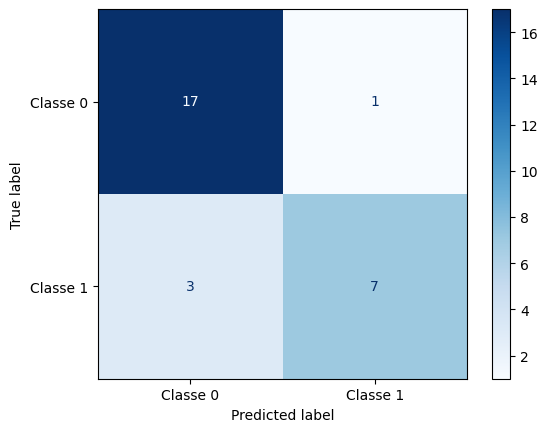

In [21]:
# ConfusionMatrixDisplay permite plotar com rótulos e cores
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')
plt.show()

### Teste

In [20]:
real_test = iris_teste['Species']
iris_teste = iris_teste.drop("Species", axis=1)
iris_teste = scaler.fit_transform(iris_teste)
pred_test = model.predict(iris_teste)

compara = pd.DataFrame({"Predito": pred_test, "Real": real_test})

In [21]:
compara

,Predito,Real
17,0,0
75,0,1
14,0,0
25,0,0
100,0,0
50,0,1
21,0,0
113,1,0
148,0,0
58,1,1


### Experimento

Teste o modelo para predizer as outras duas espécies.
Por que os valores como predição e acurácia são diferentes?